Here we will see how we can make use of our saved coordinates
With the map, we will want to apply two filter: price and price per square feet

In [23]:
import folium
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

In [24]:
df = pd.read_csv('database.csv')
df["PRICE_SQRM"] = df["PRICE"]/df["SIZE"]
df.head()

,ID,PRICE,SIZE,ROOMS,DATE,OWNER,LAT,LON,PRICE_SQRM
0,67837996,549000,45.62,2,29.04.2026,prywatny,50.656732,17.897874,12034.195528
1,67953693,710000,60.00,3,28.04.2026,prywatny,50.666950,17.937210,11833.333333
2,67954267,639000,64.12,3,28.04.2026,biuro nieruchomości,50.664387,17.933162,9965.689333
3,67926507,460000,46.61,3,28.04.2026,biuro nieruchomości,50.662900,17.897750,9869.126797
4,67686199,779000,75.61,4,28.04.2026,biuro nieruchomości,50.650100,17.854300,10302.869991


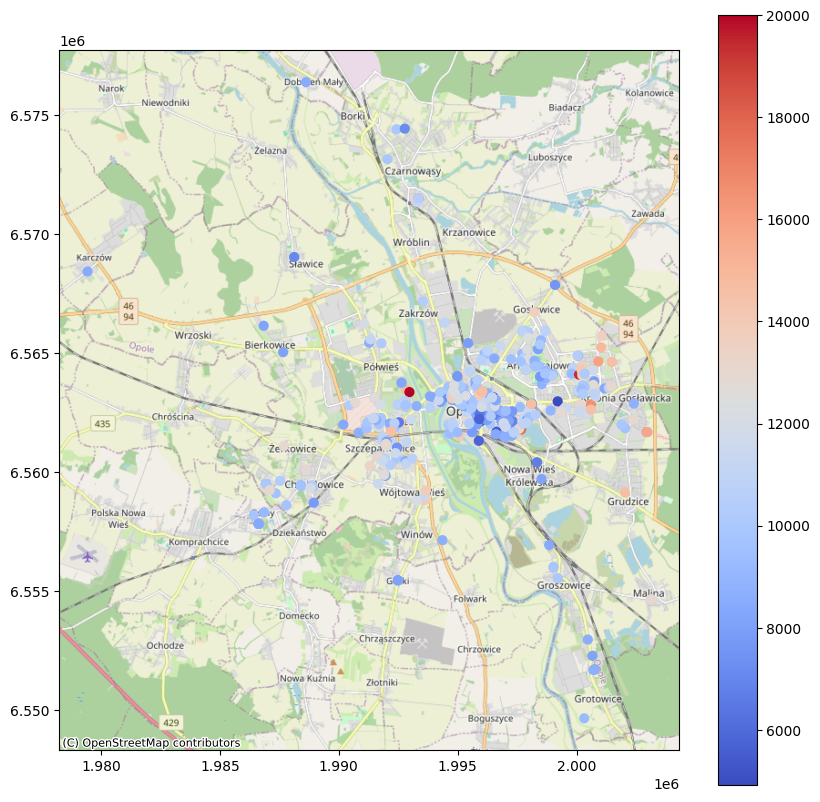

In [26]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# Create geometry column
geometry = [
    Point(xy) for xy in zip(df["LON"], df["LAT"])
]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"   # GPS coordinates
)

# Convert to web mercator for web tiles
gdf_web = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

gdf_web.plot(
    ax=ax,
    column="PRICE_SQRM",
    cmap="coolwarm", #other colormaps: viridis, plasma, inferno, magma, cividis
    markersize=40,
    legend="True"
)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

plt.show()